In [99]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_data.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [100]:
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# -------------------
# Data
# -------------------
X = df.drop("Churn", axis=1)
y = df["Churn"]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [col for col in X.columns if col not in numeric_features]

# -------------------
# Preprocessing
# -------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# -------------------
# Base Model Pipeline
# -------------------
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

# -------------------
# Hyperparameter Grid
# -------------------
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__penalty": ["l2"]
}

# -------------------
# Train/Test Split
# -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------
# Grid Search CV
# -------------------
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

# -------------------
# Best Model
# -------------------
best_model = grid_search.best_estimator_

# -------------------
# Predictions
# -------------------
y_pred = best_model.predict(X_test)

# -------------------
# Evaluation
# -------------------
print("Best Params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -------------------
# Cross Validation (Final Check)
# -------------------
scores = cross_val_score(best_model, X, y, cv=5, scoring="f1")

print("CV Scores:", scores)
print("Mean F1 Score:", scores.mean())
print("Std:", scores.std())

Best Params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV F1: 0.633966725008808
Accuracy: 0.7409510290986515
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

CV Scores: [0.63720452 0.6407563  0.62190083 0.61930011 0.61904762]
Mean F1 Score: 0.6276418752312112
Std: 0.009379108826275014


## (good std) but not optimal.

In [116]:
import os
import joblib

model = joblib.load("../models/logistic_churn_model.pkl")


In [121]:
import os
print(os.listdir("../models"))

['logistic_churn_model.pkl']


## Missing a churn customer is worse than wrongly flagging one


✔ Class imbalance handled
✔ Logistic Regression tuned
✔ Strong recall achieved
✔ Reproducible workflow

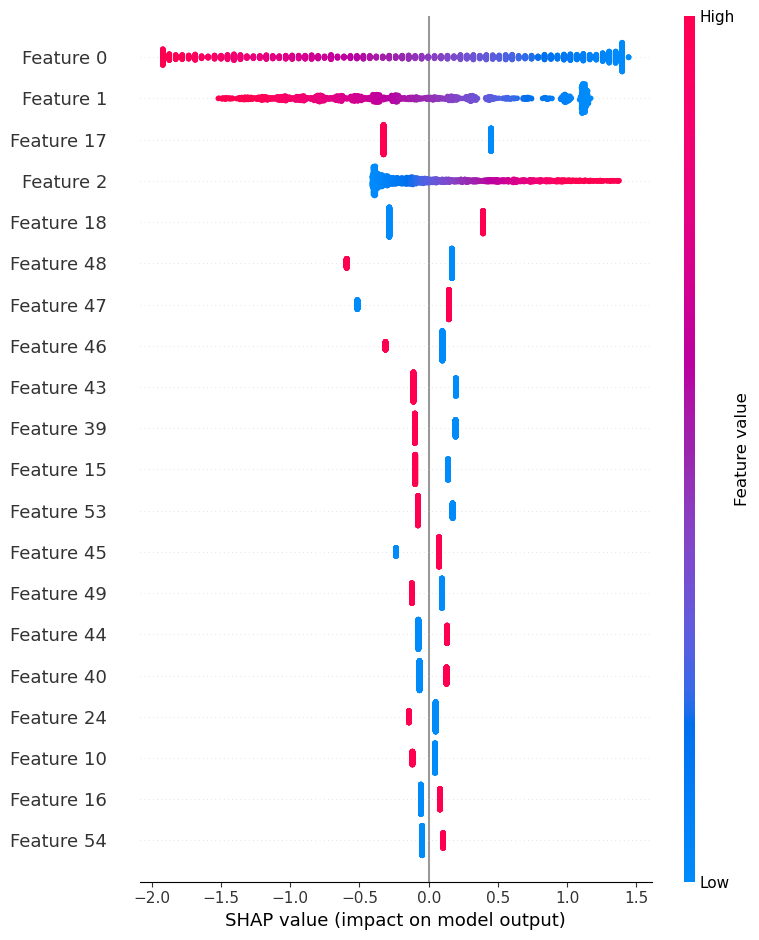

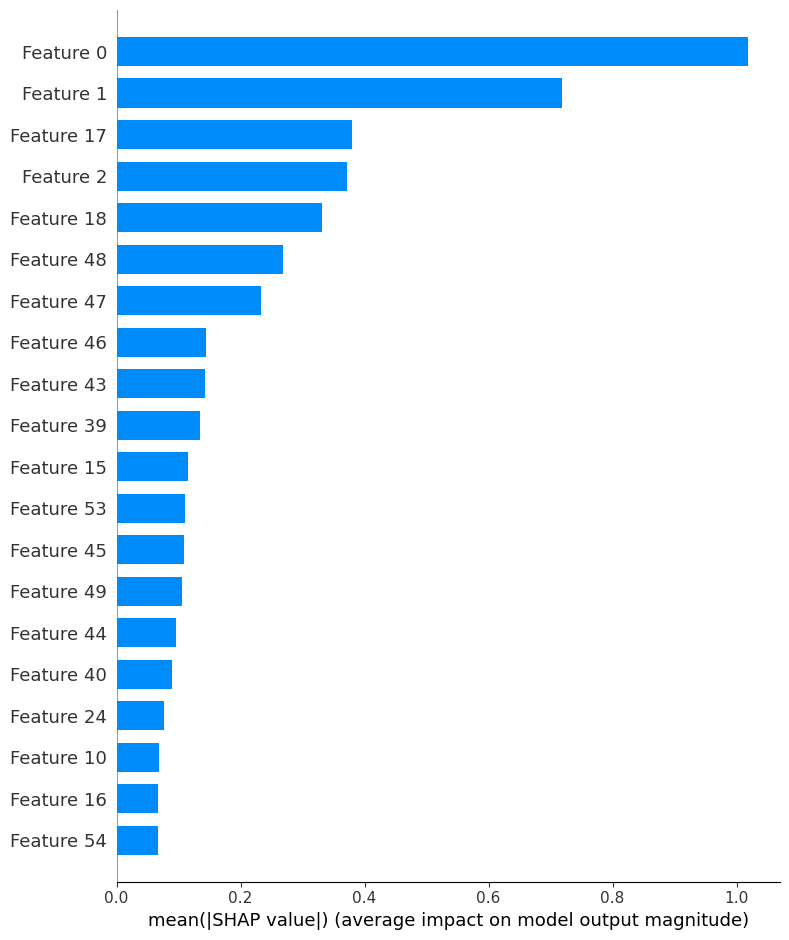

In [122]:
import shap

X_transformed = model.named_steps["preprocessor"].transform(X_test)

lr_model = model.named_steps["classifier"]

import shap

explainer = shap.LinearExplainer(lr_model, X_transformed)
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed)


shap.summary_plot(shap_values, X_transformed, plot_type="bar")




In [123]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

In [124]:
import pandas as pd

shap_df = pd.DataFrame(
    shap_values.values,
    columns=feature_names
)

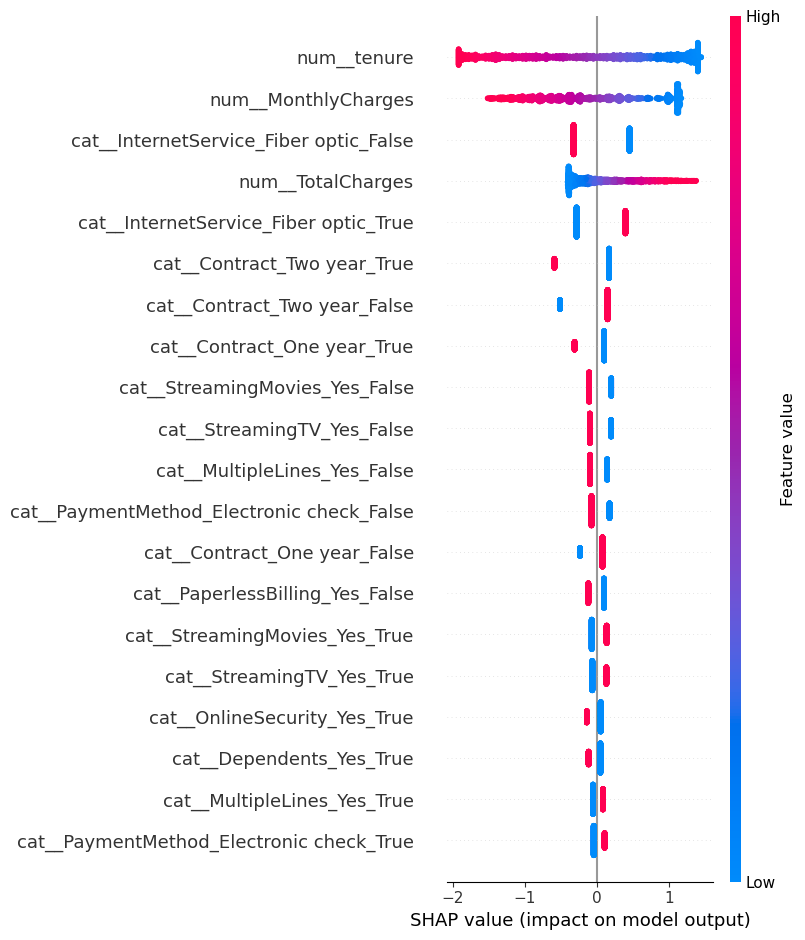

In [125]:
shap.summary_plot(shap_values.values, X_transformed, feature_names=feature_names)

## tenure → strongest factor (new customers churn more)
## MonthlyCharges → higher charges increase churn risk
## TotalCharges → reflects overall customer value/commitment
## InternetService (Fiber optic) → associated with higher churn
## Contract (Two year / One year) → long contracts reduce churn significantly